# Sub-sampling Quantum Kernels

## Overview
This tutorial has been built around the work by E. Sahin et al.* [[1]](https://arxiv.org/abs/2401.02879) and demonstrates how a sub-sampling approach can be used to overcome scalability issues within quantum kernel methods.  

The tutorial is structured as follows:

1. [Introduction](#1.-Introduction)
2. [Prepare the Dataset](#2-prepare-the-dataset)
3. [Quantum Fidelity Kernel classification](#3.-Quantum-Fidelity-Kernel-classification)
4. [Quantum Kernel Alignment](#4.-Quantum-Kernel-Alignment)
5. [The Sub-Kernel Method](#5.-The-Sub-Kernel-Method)
6. [Conclusion](#6.-Conclusion)

## 1. Introduction

Kernel methods are a cornerstone of classical machine learning, enabling algorithms like Support Vector Machines (SVMs) to tackle nonlinear problems by mapping data into higher-dimensional spaces. Quantum kernel methods extend this concept into the quantum domain, leveraging the high-dimensional space of quantum states to capture complex patterns in data. Despite their promise, quantum kernel methods, especially quantum kernel alignment (QKA), face significant scalability issues.

The goal of QKA is to optimize the quantum kernel so that it aligns well with a given target. This target could be the labels of a supervised learning problem or another kernel that captures desired properties of the data. The alignment process involves adjusting the parameters of the quantum circuit that generates the quantum states, thereby optimizing the quantum kernel. This is done by minimizing (or maximizing) the alignment metric using techniques like gradient descent or other optimizers. The need to compute the full kernel matrix during each iteration of the training process results in substantial computational overhead, particularly as the size of the dataset increases.

### 1.1. Quantum fidelity kernels and quantum kernel alignment

To build a quantum kernel matrix $K(x_i ,x_j)$, a quantum feature map, $\phi(x_i)$, is used to transform classical data $x_i$ into a corresponding quantum state $ |\phi(x_i)\rangle$. The Quantum Fidelity Kernel (QFK) between two classical data points, $x_i$ and $x_j$, is computed using the overlap of the related quantum states 
$K(x_i, x_j) = | \langle\psi ( x_i)|\psi (x_j)\rangle |^2$, 
where $|\psi (x_i)\rangle = U_{\phi}(x_i) |0\rangle^{\otimes n}$ and $U_{\phi}(x_i)$ is the unitary that implements the quantum feature map.

QKA adds a variational layer $U(\boldsymbol{\theta})$ to the kernel, where $\boldsymbol{\theta}$ are trainable parameters. The elements of the fidelity kernel matrix are computed in the same way, but now depend on $\boldsymbol{\theta}$ as shown below:

$$ K(x_i, x_j, \boldsymbol{\theta}) =  |\langle\psi (\boldsymbol{\theta}, x_i)|\psi (\boldsymbol{\theta}, x_j)\rangle |^2 $$
where $|\psi (\boldsymbol{\theta}, x_i)\rangle = U_{\phi}(x_i) U(\boldsymbol{\theta}) |0\rangle^{\otimes n} $

The training of the variational quantum kernel can be seen as finding a kernel that minimizes the upper bound of the SVM generalization error. This is equivalent to minimising a loss function $L$, expressed as

$$ L=(\boldsymbol{\theta},a) = \sum_{i} a_i - 0.5 \sum_{i,j} a_i a_j y_{i} y_{j} K(\boldsymbol{\theta},x_i, x_j) $$

where $a_i$ and $a_j$ are the optimal Lagrange multipliers, and $y$ are the labels of the binary classification problem.

### 1.2. The sub-sampling approach

In this approach, we focus on the utilization of a subset of the kernel matrix, the sub-kernel, in each step of the variational training phase until optimal parameters, $\boldsymbol{\theta}_{opt}$, are discovered. Once obtained, these parameters are used to construct the entire fidelity kernel, which is then used for QSVM training and then classification.

The workflow, represented in Figure 1.B, can be summarised as:

- *Variational parameter initialisation:* the variational parameters $\boldsymbol{\theta}$ of the quantum circuit are initialised as $\boldsymbol{\theta}_{init}$, giving an initial state $|\psi(\boldsymbol{\theta}_{init})\rangle$.
- *Variational parameters and loss function optimisation loop:* execute the optimisation loop and for each iteration, execute the following sub-steps:
    - *Dataset subsampling:* initiate by randomly selecting a distinct subset of $k$ data points from the full dataset and employ the kernel equation to construct a sub kernel, $K_{\text{sub}}$. Note that each time a new subset is selected, it is composed of previously unselected points until such a time that the entire dataset is exhausted (depending on the sub kernel and batch size), at which point previously selected points may be used again.
    - *Loss function estimation:* compute the loss function $L$ using $K_{\text{sub}}$.
    - *Loss function optimisation:* perform an optimisation step on $L$ to update the parameters $\boldsymbol{\theta}$.
- *Full kernel estimation:* utilise the optimised parameters $\boldsymbol{\theta}_{opt}$ to compute the full quantum kernel $K_f(\boldsymbol{\theta}_{opt})$.
- *Training of classifier:* implement the full kernel in an SVM model for binary classification.

![method scheme](../images/ssqk-schematic-view.jpg)

**Figure 1 A)** Quantum kernel alignment uses n qubits to encode the dataset into a feature map, estimate the kernel,
and optimize parameters θ until kernel separation improves. **B)** In the sub-sampling method, subsets with *k* elements of
the dataset are similarly processed using *n* qubits. This cycle repeats with different subsets, optimizing θ until the entire
dataset is sampled, yielding an optimized kernel. This will end with the estimation of the full dataset, optimised kernel.

## 2. Prepare the Dataset

We start by preparing the dataset. In this example, we load the file `dataset_graph7.csv` from the Quantum Kernel Training (QKT) Toolkit [[3]](https://github.com/qiskit-community/prototype-quantum-kernel-training/tree/main/data). This is the labeling Cosets with error dataset, which is synthetic dataset designed to evaluate quantum machine learning algorithm accuracies. If we inspect the dataset, we see that each sample has 14 features and the labels are binary $\pm1$.

In [2]:
import pandas as pd
import numpy as np

# Load the dataset and split into train and test sets
DATA_FILEPATH = "dataset_graph7.csv"
num_train = 92
num_test = 32

df = pd.read_csv(DATA_FILEPATH, sep=",", header=None)
train_indices = []
test_indices = []
indices = np.arange(len(df))
np.random.shuffle(indices)

train_indices = indices[:num_train]
test_indices = indices[num_train : num_train + num_test]

train_features = df.iloc[train_indices, :-1].to_numpy()
train_labels = df.iloc[train_indices, -1].to_numpy()

test_features = df.iloc[test_indices, :-1].to_numpy()
test_labels = df.iloc[test_indices, -1].to_numpy()

# The proportion of train and test datapoints can be adjusted as needed.
print("training_data: ", train_features.shape)
print("training_labels: ", train_labels.shape)
print("test_data: ", test_features.shape)
print("test_labels: ", len(test_labels))

training_data:  (92, 14)
training_labels:  (92,)
test_data:  (32, 14)
test_labels:  32


## 3. Quantum Fidelity Kernel classification.
Here we show how to create a Quantum Kernel (QK) in Qiskit and run a classification task using Qiskit machine learning's Quantum Support Vector Classifier (`QSVC`).

### 3.a. The Covariant Feature Map

In this tutorial we will be using the `CovariantFeatureMap` map taken from the QKT Toolkit [[4]](https://github.com/qiskit-community/prototype-quantum-kernel-training/blob/main/docs/background/qkernels_and_data_w_group_structure.ipynb). This feature map is tailored to the group structure of this particular dataset and is parameterised by a vector of parameters $\mathbf{\theta}$ of length equal to the number of qubits (feature dimension). 

To instantiate the `CovariantFeatureMap`, we specify:
- Feature dimension
- Entanglement structure of the quantum circuit
- Type of parametrization for the trainable parameters

In this example, we set the `feature_dimension` to that of the dataset. In addition, the `entanglement` parameter controls the structure of the fiducial state of the covariant quantum feature map. We choose `entanglement` to match the graph used to generate the dataset (a subgraph of the heavy-hexagon lattice [[5]](https://www.ibm.com/quantum/blog/heavy-hex-lattice)). With this selection, we expect our model to perform well on this dataset. However, other entanglement structures can be used if one does not have prior knowledge of what might constitute a good choice.

training parameters :  []


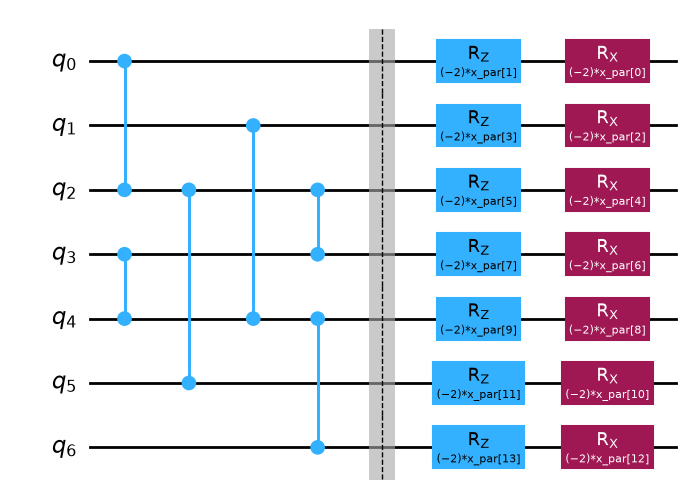

In [11]:
from qiskit_machine_learning.circuit.library import CovariantFeatureMap

num_features = np.shape(train_features)[1]
entangler_map = [[0, 2], [3, 4], [2, 5], [1, 4], [2, 3], [4, 6]]

# Creating the feature map without trainable params
# we will use this for an initial QSVC
fm_n = CovariantFeatureMap(
    feature_dimension=num_features,
    entanglement=entangler_map,
    include_training_parameters=False,
)
# With trainable params
feature_map = CovariantFeatureMap(
    feature_dimension=num_features,
    entanglement=entangler_map,
    include_training_parameters=True,
)

print("training parameters : ", [x.name for x in fm_n.training_parameters])
fm_n.draw("mpl")

### 3.b. Classification using a QSVC.

As mentioned previously, to utilise a kernel, classical or quantum, we need to perform a Classification algorithm on it. We can perform a [`QSVC`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.QSVC.html), which is an extension of sklearns SVC. The `QSVC` is initialised with a QK and when the fit method is called, it calls the QK to evaluate itself and then passes the resultant kernel to the SVC fit method.

We create a `run_QSVC` function to create and fit our `QSVC` as well as calculate some popular machine learning metrics (ROC AUC, F1, Test accuracy) to evaluate training success.

In [3]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from qiskit_machine_learning.algorithms.classifiers import QSVC

def run_QSVC(training_input, train_labels, test_input, test_labels, quantum_kernel):
    """A function to fit and score a quantum support vector classifier.

    Args:
        training_input (np.ndarray): training sample features.
        train_labels (np.ndarray): training sample labels.
        test_input (np.ndarray): testing sample features.
        test_labels (np.ndarray): testing sample labels.

    Returns:
        qsvc (QSVC): the fitted qsvc object.
        auc (float): the ROC AUC score.
        f1 (float): the f1 score.
    """
    # Create the QSVC
    qsvc = QSVC(quantum_kernel=quantum_kernel, probability=True)

    # Evaluate the kernel and fit the SVC
    qsvc.fit(training_input, train_labels)

    # predict probabilities
    predicted = qsvc.predict(test_input)
    predicted_proba = qsvc.predict_proba(test_input)
    # Calculate F1-Score and write
    f1 = f1_score(test_labels, predicted, average="weighted")
    # calculate scores
    try:
        auc = roc_auc_score(test_labels, predicted_proba, multi_class="ovo", average="weighted")
    except:
        auc = roc_auc_score(test_labels, predicted_proba[:, 1])

    acc_score = accuracy_score(test_labels, predicted)
    # summarize scores
    return qsvc, auc, f1, acc_score

Before running the `QSVC` we must first create our QK. We will utilise Qiskit machine learning's [`FidelityStatevectorKernel`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.kernels.FidelityStatevectorKernel.html#fidelitystatevectorkernel). `FidelityStatevectorKernel` is initialised with a feature map and implements a quantum kernel based on the state fidelity.


Evaluating Quantum Fidelity kernel...


/workspaces/qiskit-machine-learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


QSVC Training Runtime: 0.5524712510000427 secs
Quantum Fidelity Kernel F1 Score = 0.146
Quantum Fidelity Kernel ROC AUC = 0.749
Quantum Fidelity Kernel Accuracy Score = 0.219



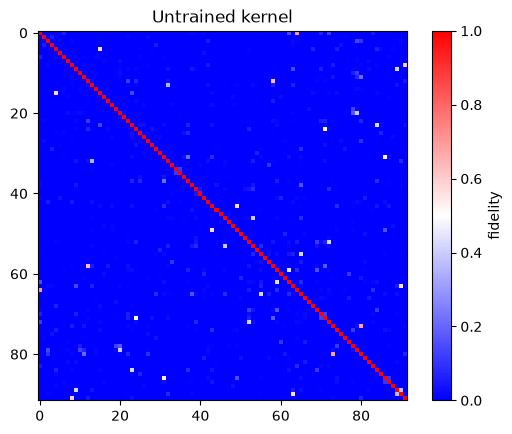

In [4]:
import matplotlib
import matplotlib.pyplot as plt

# Qiskit Machine Learning requirements
from qiskit_machine_learning.kernels import FidelityStatevectorKernel, TrainableFidelityStatevectorKernel

from timeit import default_timer as timer

fidelity_kernel = FidelityStatevectorKernel(feature_map=fm_n)
print("Evaluating Quantum Fidelity kernel...")
# Evaluate the quantum fidelity kernel
start = timer()
qsvc, auc, f1, accuracy = run_QSVC(
    train_features, train_labels, test_features, test_labels, fidelity_kernel
)
end = timer()
qsvc_runtime = end - start
print(f"QSVC Training Runtime: {qsvc_runtime} secs")
# Print results
print("Quantum Fidelity Kernel F1 Score = %.3f" % (f1))
print("Quantum Fidelity Kernel ROC AUC = %.3f" % (auc))
print("Quantum Fidelity Kernel Accuracy Score = %.3f" % (accuracy))
print()

# Visualising the untrained kernel
untrained_kernel_eval = fidelity_kernel.evaluate(x_vec=train_features)
plt.imshow(untrained_kernel_eval, cmap=matplotlib.colormaps["bwr"])
plt.colorbar(label="fidelity")
plt.title("Untrained kernel")
plt.show()

As you can see, the results of the `QSVC` indicate a poorly trained model, with all metrics showing weak results. Additionally the kernel sees little difference between fidelity for a majority of the dataset, this in part leads to the poor performance.

## 4. Quantum Kernel Alignment

We now find a way of improving the kernel using Quantum Kernel Alignment (QKA). By adding training parameters to the feature map, the kernel can be optimised for the dataset. QKA aims to maximize the intra-class overlap and minimize the inter-class overlap [[2]](https://arxiv.org/pdf/2105.03406) whilst giving an upper bound on the generalisation error, allowing the SVC to generalise well and not overfit [[6]](https://github.com/qiskit-community/prototype-quantum-kernel-training/blob/main/docs/background/svm_weighted_kernel_alignment.ipynb).

To train the quantum kernel on the dataset (samples and labels), we use the Qiskit machine learning [`QuantumKernelTrainer`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.kernels.algorithms.QuantumKernelTrainer.html#qiskit_machine_learning.kernels.algorithms.QuantumKernelTrainer) (QKT). This will take in a trainable version of `FidelityStatevectorKernel`.

To fit the kernel, we need a metric for knowing how well the current parameters $\boldsymbol\theta$ are performing. Here we use Qiskit machine learning's [`SVCLoss`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.utils.loss_functions.SVCLoss.html). Minimizing this loss over the parameters, $\boldsymbol\theta$, of the kernel is equivalent to maximizing a weighted kernel alignment, which in turn yields the smallest upper bound to the SVM generalization error for a given parameterization. See [[2](https://arxiv.org/abs/2105.03406)] for further details.

To minimize the loss we use the [Simultaneous Perturbation Stochastic Approximation](https://qiskit.org/documentation/stubs/qiskit.algorithms.optimizers.SPSA.html#qiskit.algorithms.optimizers.SPSA) (SPSA) optimizer. SPSA is an gradient descent method for optimizing systems with multiple unknown parameters.



 Training Runtime: 108.6709503369998 secs. Results: 
--------------------------------------------------------------------------------



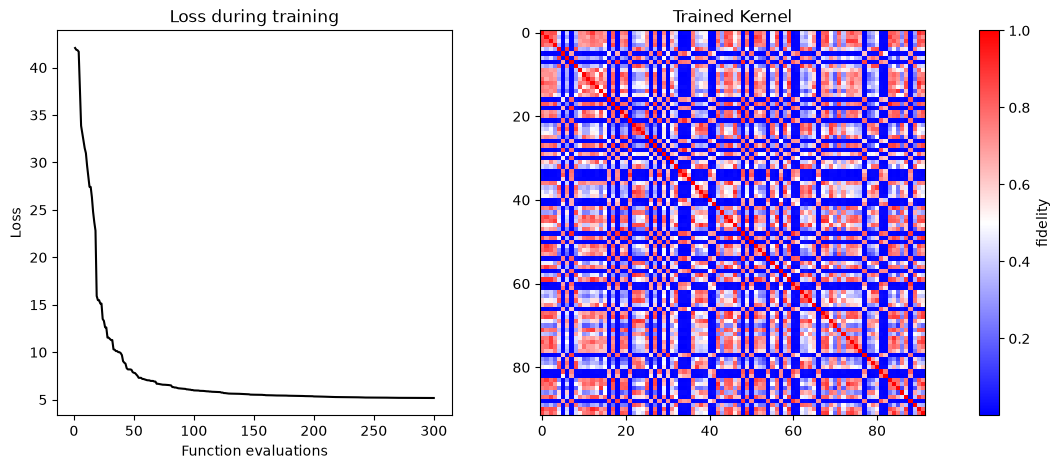

In [5]:
from qiskit_machine_learning.optimizers import SPSA
from qiskit_machine_learning.kernels.algorithms import QuantumKernelTrainer

loss_history = []
def callback(_, __, func_value, ___, ____):
    loss_history.append(func_value)

optimizer = SPSA(maxiter=300, learning_rate=0.002, perturbation=0.05, callback=callback)

# Instantiate quantum kernel
quant_kernel = TrainableFidelityStatevectorKernel(
    feature_map=feature_map, training_parameters=feature_map.training_parameters
)


init_p = 0.25 * np.random.uniform(-np.pi, np.pi, len(feature_map.training_parameters))
# Instantiate a quantum kernel trainer.
qkt = QuantumKernelTrainer(
    quantum_kernel=quant_kernel, loss="svc_loss", optimizer=optimizer, initial_point=init_p
)
# Train the kernel
start = timer()
qka_results = qkt.fit(train_features, train_labels)
end = timer()
train_time = end - start
print(f" Training Runtime: {train_time} secs. Results: ")
print("-" * 80)
print()

# Evaulating the optimised kernel on the training data
trained_kernel_eval = qka_results.quantum_kernel.evaluate(train_features)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
iters = range(1, len(loss_history) + 1)
ax[0].plot(iters, loss_history, c="k")
ax[0].set_xlabel("Function evaluations")
ax[0].set_ylabel("Loss")
ax[0].set_title("Loss during training")

im = ax[1].imshow(trained_kernel_eval, cmap=matplotlib.colormaps["bwr"])
ax[1].set_title("Trained Kernel")
fig.colorbar(im, ax=ax, label="fidelity")
plt.show()

We can see the above loss graph shows us the loss has converged and the outputted trained kernel has much more contrast than our untrained kernel. This is the action of increasing intra-class fidelities and decreasing inter-class fidelities. We can next run a `QSVC` to see the increase in performance when using the Aligned QK.

In [6]:
# Evaluate the quantum fidelity kernel
start = timer()
qsvc, auc, f1, accuracy = run_QSVC(
    train_features, train_labels, test_features, test_labels, qka_results.quantum_kernel
)
end = timer()
qsvc_runtime = end - start
print(f"QSVC Training Runtime: {qsvc_runtime} secs")
# Print results
print("Quantum Fidelity Kernel F1 Score = %.3f" % (f1))
print("Quantum Fidelity Kernel ROC AUC = %.3f" % (auc))
print("Quantum Fidelity Kernel Accuracy Score = %.3f" % (accuracy))
print(
    "Increase in overall time by aligning kernel = %.3f"
    % ((train_time + qsvc_runtime) * 100 / qsvc_runtime),
    "%",
)

/workspaces/qiskit-machine-learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


QSVC Training Runtime: 0.45422449300031076 secs
Quantum Fidelity Kernel F1 Score = 1.000
Quantum Fidelity Kernel ROC AUC = 1.000
Quantum Fidelity Kernel Accuracy Score = 1.000
Increase in overall time by aligning kernel = 24024.503 %


We can see the `QSVC` using the trained kernel performs significantly better. However, aligning the kernel increases runtime by a signficant margin, this increase is exactly correlated to the number of optimiser iterations. This is a steep cost for the increase in performance as the kernel calculation is already _quadratic_ with number of features and this must be done at each iteration step. Additionally, there are other considerations with QKs like shot noise, higher error rates and the need for error mitigation or correction. 

## 5. The Sub-Kernel Method

The sub-kernel method aims to tackle this runtime issue by randomly selecting a subset of the data points, referred to as a "sub-kernel" at each iteration.

If $\mathcal{D}$ is our dataset and $\mathcal{D'}$ is a randomly sampled subset of $\mathcal{D}$ for each iteration $i$, we sample a subset $\mathcal{D}_i' \subset \mathcal{D}$ of size $k \ll m$, where $m$ is the size of the full dataset. We then compute the fidelity kernel $\mathbf{K}_{\mathcal{D}_i'}$ on the subset $\mathcal{D}_i'$ and update the variational parameters accordingly. To reduce errors induced by sub-sampling, multiple sub-kernels can be batched at each iteration and their loss averaged before updating parameters.

To realise the sub-kernel method in Qiskit, we utlilize the `BatchedSVCLoss` loss function. This generates a batch of sub-kernels, where each batch contains a number of samples from each label and computes the average loss.

The sub-kernel method is performed as follows:
1. Initialise the `TrainableFidelityStatevectorKernel`.
2. Initialise the `QuantumKernelTrainer` using `BatchesSVCLoss`.
3. Fit the `QuantumKernelTrainer`. 
4. Retrieve the optimised kernel from the `QuantumKernelTrainerResult` returned from the `.fit()` method.
5. Run the optimised kernel through the `run_QSVC` function.

In [7]:
from qiskit_machine_learning.utils.loss_functions import BatchedSVCLoss

def run_subsampling_kernel(optimizer, quantum_kernel, batch_size, sub_kernel_size, initial_point):

    # Instantiate Sub-kernel loss
    loss = BatchedSVCLoss(
        train_features,
        train_labels,
        minibatch_size=batch_size,
        sub_kernel_size=sub_kernel_size,
        balanced_batch=False,
        shuffle=True,
        encoder=None,
    )

    # Instantiate a quantum kernel trainer.
    qkt = QuantumKernelTrainer(
        quantum_kernel=quantum_kernel,
        loss=loss,
        optimizer=optimizer,
        initial_point=initial_point,
    )

    # Train the kernel
    start = timer()
    qka_results = qkt.fit(train_features, train_labels)
    end = timer()
    train_time = end - start
    optimized_kernel = qka_results.quantum_kernel

    start = timer()
    # Train the QSVC using optimized quantum fidelity kernel
    qsvc, auc, f1, accuracy = run_QSVC(
        train_features,
        train_labels,
        test_features,
        test_labels,
        optimized_kernel,
    )
    end = timer()
    qsvc_runtime = end - start

    sk_size = len(train_features) if sub_kernel_size == None else int(sub_kernel_size)
    num_support_vectors = len(qsvc.support_)
    plot_data = (len(train_features) * np.array(loss.loss_arr) / (sk_size * num_support_vectors))

    return {
            "ROC": auc,
            "F1": f1,
            "accuracy": accuracy,
            "sub_kernel_size": sub_kernel_size,
            "batch_size": batch_size,
            "train_time": train_time,
            "qsvc_runtime": qsvc_runtime,
            "plot_data": plot_data.tolist(),
            "loss": loss.loss_arr,
            "opt_params": qka_results.optimal_point.tolist(),
        }
        

In [8]:
def plot_average_loss_with_variance(losses, N=10):
    """
    Plots the average and variance of training loss over every N steps.

    Args:
        losses (float): loss values to plot.
        N (int): Number of steps to average over.

    Returns:
        None
    """

    # Calculate the means and variances over every N steps
    means = []
    variances = []

    for i in range(0, len(losses), N):
        # Handle the last data point if it's smaller than N
        end = i + N
        if end > len(losses) and len(losses[i:]) < N:
            chunk = np.concatenate([losses[i - (N - len(losses[i:])) : i], losses[i:]])
        else:
            chunk = losses[i:end]

        means.append(np.mean(chunk))
        variances.append(np.var(chunk))

    # Create an x-axis for the plot
    x = np.arange(0, len(losses), N)[: len(means)]

    # Plot the means and variances
    plt.plot(x, means, "-o", label="Mean Loss")
    plt.fill_between(
        x,
        np.array(means) - np.array(variances),
        np.array(means) + np.array(variances),
        color="gray",
        alpha=0.2,
        label="Variance",
    )

    # Set the title and labels for the plot
    plt.title("Training Loss over Time")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.legend()

    # Display the plot
    plt.show()

We'll start small by using a batch_size of 1 and a sub_kernel_size of 4.

/workspaces/qiskit-machine-learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


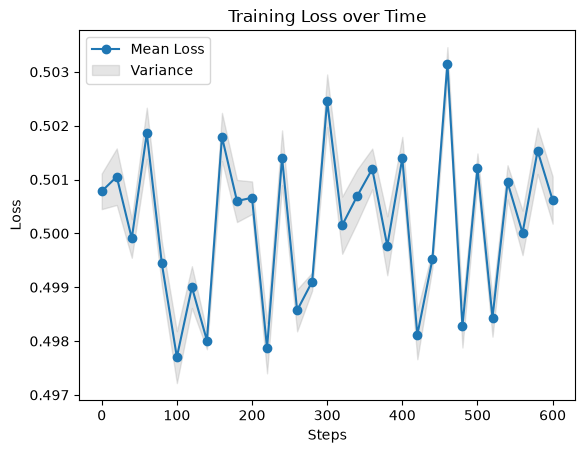

In [9]:
quantum_kernel = TrainableFidelityStatevectorKernel(
                feature_map=feature_map, training_parameters=feature_map.training_parameters
            )

optimizer = SPSA(maxiter=300, learning_rate=0.002, perturbation=0.05)
batch_size = 1
sub_kernel_size = 4

initial_point = 0.25 * np.random.uniform(-np.pi, np.pi, len(feature_map.training_parameters))
run_data = run_subsampling_kernel(optimizer, quantum_kernel, batch_size, sub_kernel_size, initial_point)
plot_data = run_data["plot_data"]
plot_average_loss_with_variance(plot_data, N=20)

We can now run this method for various batch and sub-kernel sizes to see the effect on training time and performance.


In [10]:
batch_sizes = [1, 4, 8]
sub_kernel_sizes = [4, 8, 16, 32, None]

opt_results = []
for sub_kernel_size in sub_kernel_sizes:
    for batch_size in batch_sizes:

        optimizer = SPSA(maxiter=300, learning_rate=0.002, perturbation=0.05)
        initial_point = 0.25 * np.random.uniform(-np.pi, np.pi, len(feature_map.training_parameters))

        print(f"sub_kernel_size={sub_kernel_size} | batch_size={batch_size}")
        
        run_data = run_subsampling_kernel(optimizer, quantum_kernel, batch_size, sub_kernel_size, initial_point)
        opt_results.append(run_data)

        if sub_kernel_size==None:
            break
       

sub_kernel_size=4 | batch_size=1


/workspaces/qiskit-machine-learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


sub_kernel_size=4 | batch_size=4


/workspaces/qiskit-machine-learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


sub_kernel_size=4 | batch_size=8


...

/workspaces/qiskit-machine-learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


sub_kernel_size=32 | batch_size=8


/workspaces/qiskit-machine-learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


sub_kernel_size=None | batch_size=1


/workspaces/qiskit-machine-learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


         ROC        F1  Accuracy  Sub kernel size  Batch size  Train time (s)
0   0.906883  0.779753   0.78125              4.0         1.0        3.069716
1   0.821862  0.720158   0.71875              4.0         4.0       11.859909
2   0.809717  0.721244   0.71875              4.0         8.0       23.754432
3   0.906883  0.782319   0.78125              8.0         1.0        5.227782
4   0.914980  0.813988   0.81250              8.0         4.0       21.339233
5   0.846154  0.751984   0.75000              8.0         8.0       42.783222
6   0.623482  0.627941   0.62500             16.0         1.0       10.472489
7   1.000000  1.000000   1.00000             16.0         4.0       40.741826
8   1.000000  1.000000   1.00000             16.0         8.0       53.243278
9   1.000000  1.000000   1.00000             32.0         1.0       21.379210
10  1.000000  1.000000   1.00000             32.0         4.0       42.203527
11  0.995951  0.968906   0.96875             32.0         8.0   

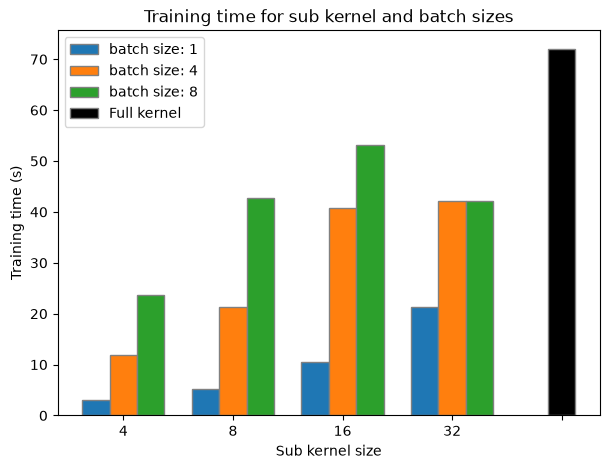

In [11]:
def plot_sub_kernel_experiments(results):
    """
    Plotting function to show a bar graph of the training time increasing with sub-kernel size and number of kernels evaluated.
    Keep in mind this fucntion is expecting the final sub kernel size to be None for comparison.
    Args:
       results (dict): plot data from the sub-kernel experiments.

    Returns:
       None

    """

    selected_data = np.ones((len(results), 6))
    for i in range(len(results)):
        line = np.ones(6)
        line[0] = results[i].get("ROC")
        line[1] = results[i].get("F1")
        line[2] = results[i].get("accuracy")
        line[3] = results[i].get("sub_kernel_size")
        line[4] = results[i].get("batch_size")
        line[5] = results[i].get("train_time")
        selected_data[i] = line

    bar_chart_data = np.ones((len(batch_sizes), len(sub_kernel_sizes) - 1, 6))
    for j in range(len(batch_sizes)):
        for k in range(len(sub_kernel_sizes) - 1):
            bar_chart_data[j, k] = selected_data[len(batch_sizes) * k + j]

    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    barWidth = 0.25
    br = np.arange(len(sub_kernel_sizes) - 1)
    for l in range(len(batch_sizes)):
        label = "batch size: " + str(batch_sizes[l])
        if l > 0:
            br = [x + barWidth for x in br]
        ax.bar(br, bar_chart_data[l][:, -1], width=barWidth, edgecolor="grey", label=label)
    ax.bar(
        len(sub_kernel_sizes) - 1 + barWidth,
        selected_data[-1, -1],
        color="black",
        width=barWidth,
        edgecolor="grey",
        label="Full kernel",
    )
    ax.set_ylabel("Training time (s)")
    ax.set_xlabel("Sub kernel size")
    ax.set_xticks([r + barWidth for r in range(len(sub_kernel_sizes))], sub_kernel_sizes)
    ax.set_title("Training time for sub kernel and batch sizes")
    ax.legend()

    cols = ["ROC", "F1", "Accuracy", "Sub kernel size", "Batch size", "Train time (s)"]
    df = pd.DataFrame(selected_data, columns=cols)
    print(df)


plot_sub_kernel_experiments(opt_results)

Analyzing the data, we can see a trend, the larger the sub-kernel and the greater the batch size the better the model performs. This is intuitively correct, we knew that doing a QSVC using the full kernel worked very well already. The interesting thing we can note is that around the 16 size kernel mark we are already able to start replicating the performance of the full kernel training whilst drastically decreasing training time. This is showing the method working, that we can approximate for the whole dataset using these sub-kernels. 

## 6. Conclusion

In this tutorial:

* We reviewed the fundamentals of quantum kernels 
* We demonstrated how quantum kernel alignment improves performance but at a cost to runtime
* We introduced the sub-sampling method
* We have demonstrated how to implement the sub-sampling method for various batch and sub-kernel sizes 
* We have demonstrated how the sub-sampling method can be used to reduce runtime while still maintaining comparable accuracy to the full kernel

## References
1. Efficient Parameter Optimisation for Quantum Kernel Alignment: A Sub-sampling Approach in Variational Training, M. Emre Sahin and Benjamin C. B. Symons and Pushpak Pati and Fayyaz Minhas and Declan Millar and Maria Gabrani and Jan Lukas Robertus and Stefano Mensa, 2024, https://arxiv.org/abs/2401.02879
2. Covariant quantum kernels for data with group structure, Glick, Jennifer R. and Gujarati, Tanvi P. and Córcoles, Antonio D. and Kim, Youngseok and Kandala, Abhinav and Gambetta, Jay M. and Temme, Kristan, 2024, https://arxiv.org/abs/2105.03406
3. Quantum Kernel Training Toolkit, Jennifer R. Glick and Tanvi P. Gujarati, 2024, https://github.com/qiskit-community/prototype-quantum-kernel-training/tree/main/data
4. Quantum Kernel Training Toolkit, Jennifer R. Glick and Tanvi P. Gujarati, 2024, https://github.com/qiskit-community/prototype-quantum-kernel-training/blob/main/docs/background/qkernels_and_data_w_group_structure.ipynb
5. The IBM Quantum heavy hex lattice, Paul Nation, Hanhee Paik, Andrew Cross, Zaira Nazario, 2021, https://www.ibm.com/quantum/blog/heavy-hex-lattice
6. Quantum Kernel Training Toolkit, Jennifer R. Glick and Tanvi P. Gujarati, 2024, https://github.com/qiskit-community/prototype-quantum-kernel-training/blob/main/docs/background/svm_weighted_kernel_alignment.ipynb

In [12]:
import tutorial_magics

%qiskit_version_table
%qiskit_copyright